# State Estimation with a Kalman Filter

## Objective

Introduce the Kalman filter as a tool for estimating the underlying state of a system when observations are noisy.

This notebook demonstrates how a simple recursive estimator can recover structure from imperfect measurements. The exercise uses a synthetic time series to illustrate the relationship between:

- the true system signal
- noisy observations
- the estimated state produced by the filter

The goal is to develop intuition about how state estimation models behave and how their assumptions influence the output. 

## Method Overview
The exercise follows three steps:

1. **Generate a synthetic signal**

    Create a periodic system with added measurement noise.

2. **Construct a simple Kalman filter**

    Use a minimal random-walk state model.


3. **Compare results**

    Visualize the relationship between the true signal, observations, and  the filtered estimate.

This example intentionally uses a **simplified model** so that the behavior of the estimaror can be clearly observed. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(72)

## Generate a Synthetic System
We begin by constructing a simple periodic signal and simulating noisy observations. 

This provides a controlled environment for examining how the Kalman filter processes imperfect measurements. 

In [2]:
t = np.arange(0, 200)

true_signal = np.sin(2*np.pi*t/30)

noise = np.random.normal(0, 0.4, len(t))

observations = true_signal + noise

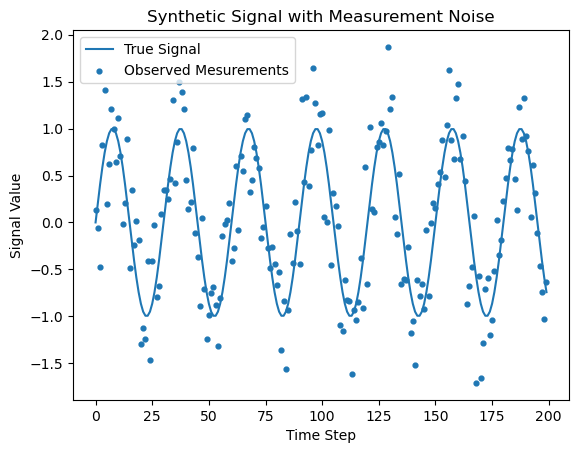

In [21]:
plt.plot(true_signal, label="True Signal")
plt.scatter(t, observations, s=12, label="Observed Mesurements")

plt.legend()
plt.title("Synthetic Signal with Measurement Noise")
plt.xlabel("Time Step")
plt.ylabel("Signal Value")

plt.show()

## Construct a Simple Kalman Filter
Next, we build a minimal Kalman filter to estimate the underlying system state from noisy observations.

For this example, we use a **one-dimensional state model** with a **random walk assumption**:

$$
\text{x}_t \;= \;\text{x}_t-1\; + \;\text{w}_t\newline
$$
$$
\text {z}_t\; = \;\text{x}_t\; + \;\text{v}_t
$$

where:
- $\text{x}_t$ is the hidden state
- $\text{z}_t$ is the observed measurement
- $\text{w}_t$ is process noise
- $\text{v}_t$ is measurement noise

Deliberately simple- the synthetic signal is periodic, but the filter does not explicitly model periodic behavior. That mismatch is useful because it lets us observe how the estimator behaves under simplified assumptions.  

In [4]:
x = np.zeros(len(t)) #array storage for the estimated state
P = np.zeros(len(t)) #array storage for the state uncertainty

Q = 0.01 # process noise for variance
R = 0.2  # the state of uncertainty

## Recursive Filter Update
At each time step, the filter performs two stages:

1. **Predict**

    Estimate the next state and uncertainty based on the previous step

3. **Update**

   Adjust that prediction using the new observation

In [7]:
for i in range(1, len(t)):

    # predict
    x_pred = x[i - 1]
    P_pred = P[i - 1] + Q

    # Kalman gain
    K = P_pred / (P_pred + R)

    # Update
    x[i] = x_pred + K * (observations[i] - x_pred)
    P[i] = (1 - K) * P_pred

# The current state is similar to the previous state, with some uncertainty
# larger Q makes the filter more responsive to change
# Larger R makes the filer trust the observations less
# Using fixed values to establish a baseline result

In [8]:
# Chech the estimated state

x[:10], P[:10]

(array([ 0.        , -0.00304343, -0.04516184,  0.06085132,  0.25928561,
         0.24948019,  0.31512874,  0.48090113,  0.57862553,  0.59210421]),
 array([0.        , 0.00952381, 0.01778742, 0.02439768, 0.02934984,
        0.03288061, 0.03531003, 0.03694103, 0.03801801, 0.03872139]))

Quick read: 
- $\text{x}$ moves away from 0, indicating the filter is updating correctly.
- $\text{P}$ rises quickly from 0 and then tapers toward a stable range which is the target of this setup
- The estimated state is moving smoothly rather than jumping with evert observation, so the filter is already acting as a noise-suppressing estimator. 

## Compare the Estimated State to the True Signal and Observations
Visualizing:
- the true underlying signal
- the noisy observations
- the Kalman filter estimate

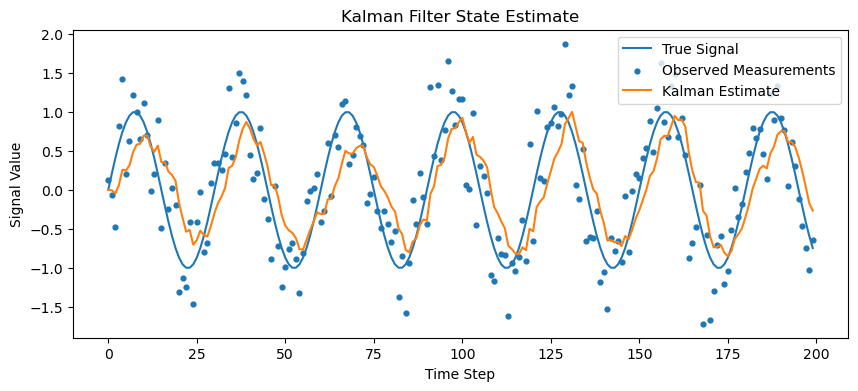

In [9]:
plt.figure(figsize=(10, 4))

plt.plot(t, true_signal, label="True Signal")
plt.scatter(t, observations, s=12, label="Observed Measurements")
plt.plot(t, x, label="Kalman Estimate")

plt.title("Kalman Filter State Estimate")
plt.xlabel("Time Step")
plt.ylabel("Signal Value")
plt.legend()
plt.show()

## Interpretation

The Kalman estimate is smoother than the raw observations and captures the overall structure of the signal. The estimate appears slightly delayed reltive to the true signal, which is expected given the filter's recursive update process and the simplified state model.

The filtered estimate aligns more closely with the observed measurements than with the underlying signal because the filter only has access to noisy data, not the true data generating process. As the sequence progresses, the estimate becomes more stable, suggesting that the recursive updtaes are gradually producing a more coherent approximation of the latent state. 

## Examine the Effect of Process Noise

The process noice variance $\text{Q}$ controls how much of the filter expects the hidden state to change from one step to the next.

In practical terms:
- a **smaller** $\text{Q}$ makes the estimate smoother and more conservative
- a **larger** $\text{Q}$ makes the estimate more responsive to new measurements

 To observe the effect, we ca rerun te filter with a larger process noise value.

In [14]:
x_high_q = np.zeros(len(t))
P_high_q = np.zeros(len(t))

Q_high = 0.1
R = 0.2

for i in range(1, len(t)):
    x_pred = x_high_q[i - 1]
    P_pred = P_high_q[i - 1] + Q_high

    K = P_pred / (P_pred + R)

    x_high_q[i] = x_pred + K * (observations[i] - x_pred)
    P_high_q[i] = (1 - K) * P_pred

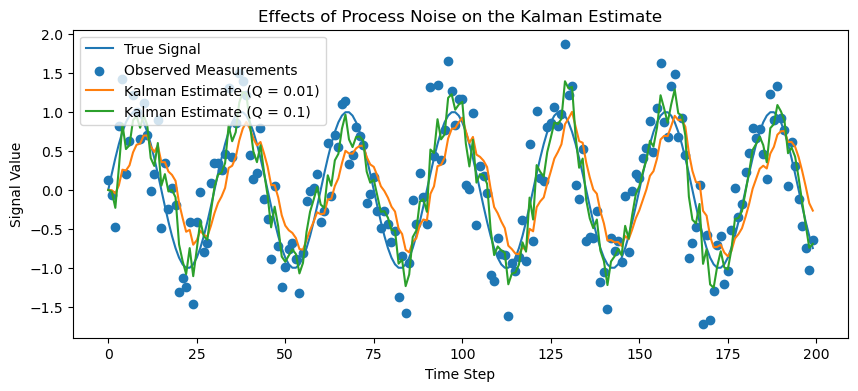

In [20]:
plt.figure(figsize=(10,4))

plt.plot(t, true_signal, label="True Signal")
plt.scatter(t, observations, label="Observed Measurements")
plt.plot(t, x, label="Kalman Estimate (Q = 0.01)")
plt.plot(t, x_high_q, label="Kalman Estimate (Q = 0.1)")

plt.title("Effects of Process Noise on the Kalman Estimate")
plt.xlabel("Time Step")
plt.ylabel("Signal Value")
plt.legend()
plt.show()

## Interpretation of Increase Process Noise

When the process noise variance $\text{Q}$ is increased, the Kalman filter assumes that the underlyig system may change more rapidly from one time-step to the next. 

As a result, the filter places **less trust in its previous estimate** and *more weight on the current obsevation*. 

This produces two visible effects in the plot:

1. **Reduced Lag**
 
   The estimator responds more quickly to changes in the observed signal. Because the filter adapts faster, the estimated state aligns more closely with the timing of peaks and troughs in the underlying signal.

2. **Close tracking of the observed data**

   The estimate follows the observations more closely, making the reconstructed signal appear more accurate in this example.

   
----------------------------------------------------------------------------

### Summary

This exercise introdued a simple Kalman filter for estimating the underlying state of a noisy system. Using a synthetis periodic signal allowed us to compare the estimated state with th the true sgnal and the observed measurements.

Key observations from the experiment include:
* The Kalman filter produces a smoothed estimate of the underlying signal. 
* The estimate may lag the true signal when the process noise assumption is small.
* Increasing the process noise variance improves responsiveness but reduces smoothing.

This example illustrates how the behavior of a recursive estimator is strongly influenced by model assumptions about system dynamics and measurement uncertainty.